# 기업 수요 교육과정 우선순위 분석

#### 설문 문항 구성

| 구분 | 항목 | 설명 |
|------|------|------|
| 응답자 정보 | Info 01 | 응답자 이름 (익명화) |
| 응답자 정보 | Info 02 | 기업명 (익명화) |
| 응답자 정보 | Info 03 | 직위 / 역할 |
| 응답자 정보 | Info 04 | 근무 지역 |
| 교육과정 평가 문항 | 중요도 (Importance) | 해당 교육 과정이 얼마나 필요하다고 인식하는가 |
| 교육과정 평가 문항 | 실행도 (Execution) | 현재 조직 내에서 해당 교육이 얼마나 충분히 수행되고 있는가 |

- 모든 평가 문항은 5점 Likert 척도로 측정되었습니다.

| 척도 | 의미 |
|------|------|
| 1 | 매우 낮음 |
| 2 | 낮음 |
| 3 | 보통 |
| 4 | 높음 |
| 5 | 매우 높음 |

#### 도메인 및 교육과정 구성

<details>
<summary>도메인 A — 현장 데이터 분석</summary>

- Course_A01 : 생산 데이터 이해 및 기초 통계  
- Course_A02 : 엑셀 기반 제조 데이터 분석  
- Course_A03 : SQL 기반 생산 데이터 추출  
- Course_A04 : 공정 이상 탐지 데이터 분석  
- Course_A05 : 제조 KPI 대시보드 설계  
- Course_A06 : 불량 데이터 패턴 분석  
- Course_A07 : 설비 로그 데이터 해석  
- Course_A08 : 데이터 기반 개선 과제 도출  
- Course_A09 : 현장 데이터 시각화 실무  

</details>

<details>
<summary>도메인 B — 품질·안전 관리</summary>

- Course_B01 : 제조 품질 관리 기초  
- Course_B02 : 불량 원인 분석 실무  
- Course_B03 : 공정 품질 모니터링 체계  
- Course_B04 : 8D 리포트 작성 실무  
- Course_B05 : ISO 품질 시스템 이해  
- Course_B06 : 산업 안전 관리 실무  

</details>

<details>
<summary>도메인 C — 스마트설비·자동화</summary>

- Course_C01 : 스마트팩토리 개념 이해  
- Course_C02 : PLC 기초 및 자동화 원리  
- Course_C03 : 설비 IoT 데이터 수집  
- Course_C04 : 예지보전 실무  
- Course_C05 : 설비 OEE 분석  
- Course_C06 : MES 운영 실무  
- Course_C07 : 자동화 설비 트러블 대응  
- Course_C08 : 스마트설비 구축 전략  
- Course_C09 : 설비 데이터 활용 개선  

</details>

<details>
<summary>도메인 D — 생산계획·공정관리</summary>

- Course_D01 : 생산 계획 수립 기초  
- Course_D02 : 공정 흐름 최적화  
- Course_D03 : 린 생산 방식 이해  
- Course_D04 : 공정 병목 분석  
- Course_D05 : ERP 기반 생산 관리  
- Course_D06 : 생산 운영 성과 관리  

</details>

## 라이브러리 로드

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 글꼴 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 데이터 로드

- 과정 단위 중요도 / 실행도 설문 구조
- 결측값 없는 mock 데이터 사용

In [48]:
df = pd.read_excel("../data/mock_survey.xlsx")

print(df.shape)
df.head()

(60, 64)


,info_01,info_02,info_03,info_04,Course_A01_Importance,Course_A01_Execution,Course_A02_Importance,Course_A02_Execution,Course_A03_Importance,Course_A03_Execution,...,Course_D02_Importance,Course_D02_Execution,Course_D03_Importance,Course_D03_Execution,Course_D04_Importance,Course_D04_Execution,Course_D05_Importance,Course_D05_Execution,Course_D06_Importance,Course_D06_Execution
0,User_1,SmartFactory_Corp_1,Tech Lead,Gyeonggi,2,2,4,3,4,1,...,3,2,1,1,2,2,2,1,1,2
1,User_2,SmartFactory_Corp_2,Production Manager,Gyeonggi,2,2,3,2,3,1,...,4,4,1,2,2,2,3,1,1,2
2,User_3,SmartFactory_Corp_3,Plant Manager,Gyeonggi,2,3,3,3,4,1,...,3,3,1,1,2,2,2,1,2,3
3,User_4,SmartFactory_Corp_4,Plant Manager,Incheon,3,1,4,3,3,1,...,3,3,2,1,2,3,2,2,2,2
4,User_5,SmartFactory_Corp_5,Tech Lead,Busan,1,3,3,4,3,1,...,3,3,2,1,2,3,3,1,2,1


## 과정 컬럼 탐색 

- Raw 데이터에서 과정 관련 컬럼만 자동 추출 <br/>
→ 과정 수 변동 대응 가능

In [49]:
# "Course_" 포함 컬럼만 필터링
course_cols = [col for col in df.columns if "Course_" in col]

# 과정 코드만 추출 (Importance / Execution 중복 제거)
courses = sorted(set("_".join(col.split("_")[:2]) for col in course_cols))

print(f"총 과정 수: {len(courses)}")
courses[:5]

총 과정 수: 30


['Course_A01', 'Course_A02', 'Course_A03', 'Course_A04', 'Course_A05']

# 과정 평균 집계 

- 중요도 평균 / 실행도 평균 / GAP 계산
- GAP = 중요도 − 실행도

In [50]:
rows = []

for c in courses:
    
    # 각 과정별
    imp_mean = df[f"{c}_Importance"].mean() # 중요도 평균
    exe_mean = df[f"{c}_Execution"].mean() # 실행도 평균
    gap = imp_mean - exe_mean # 차이 (GAP)
    
    rows.append([c, imp_mean, exe_mean, gap])

summary_df = pd.DataFrame(
    rows,
    columns=["과정코드", "중요도 평균", "실행도 평균", "GAP"]
)

summary_df[["중요도 평균", "실행도 평균", "GAP"]] = \
    summary_df[["중요도 평균", "실행도 평균", "GAP"]].round(2)

summary_df.head()

,과정코드,중요도 평균,실행도 평균,GAP
0,Course_A01,2.15,2.10,0.05
1,Course_A02,3.45,3.20,0.25
2,Course_A03,3.62,1.12,2.50
3,Course_A04,4.13,1.35,2.78
4,Course_A05,3.38,3.23,0.15


# 과정 분류

- GAP + 중요도 + 실행도 기준으로 운영 전략 구분

| 분류 | 판단 기준 | 해석 |
|------|------------|------|
| **우선 개설** | GAP ≥ 0.4 & 중요도 평균 ≥ 3.0 | 중요도는 높으나 실행 수준이 낮은 영역 → 신규 교육 개설 우선 검토 |
| **보완 필요** | GAP ≥ 0.4 & 중요도 평균 < 3.0 | 중요도 인식 및 활용 수준 개선 필요 → 교육 내용/운영 방식 보완 |
| **안정 운영** | GAP < 0.2 & 실행도 평균 ≥ 3.0 | 중요도 및 실행 수준 모두 안정적 → 현행 과정 유지 가능 |
| **수요 낮음** | GAP < 0.2 & 중요도 평균 < 2.0 | 필요성 및 활용도 모두 낮음 → 운영 축소 또는 제외 검토 |
| **검토 필요** | 기타 영역 | 기업 간 인식 편차 존재 → 추가 분석 또는 전략적 판단 필요 |

- 본 분석의 목적은 통계적 유의성 검정이 아닌 **의사결정 지원을 위한 우선순위 분류**
- GAP 값의 상대적 크기를 기준으로 개선 필요 구간을 식별하기 위해 **운영상 기준값 0.4** 설정

In [51]:
def classify(row):
    
    gap = row["GAP"]
    imp = row["중요도 평균"]
    exe = row["실행도 평균"]
    
    if gap >= 0.4 and imp >= 3.0:
        return "우선 개설"
    
    elif gap >= 0.4 and imp < 3.0:
        return "보완 필요"
    
    elif gap < 0.2 and exe >= 3.0:
        return "안정 운영"
    
    elif gap < 0.2 and imp < 2.0:
        return "수요 낮음"
    
    else:
        return "검토 필요"

summary_df["해석"] = summary_df.apply(classify, axis=1)

summary_df["해석"].value_counts()

해석
검토 필요    15
보완 필요     6
우선 개설     5
안정 운영     4
Name: count, dtype: int64

# 시각화 - GAP 상위 10개 교육과정

- 요구 대비 부족 수준이 큰 과정 식별 <br/>
→ 교육 개설의 우선순위 판단

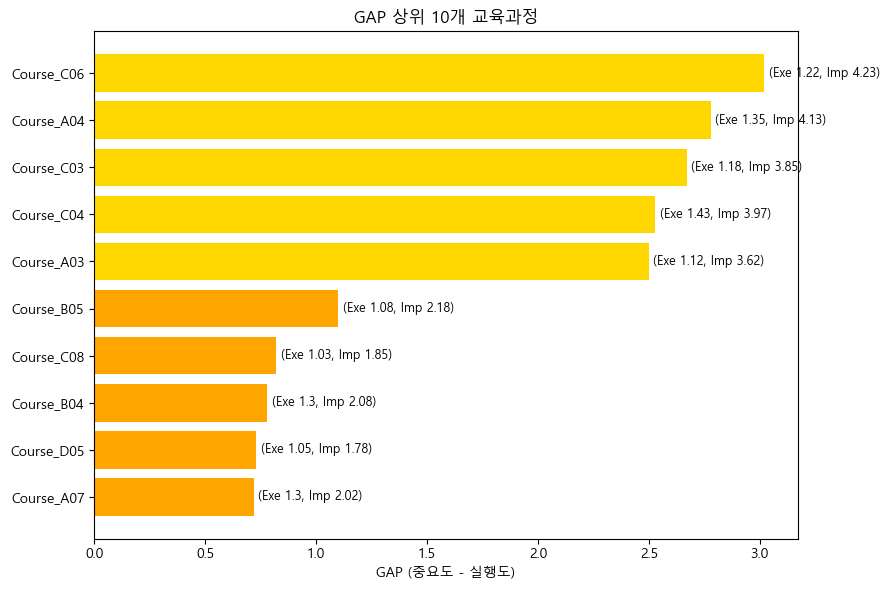

In [52]:
color_map = {
    "우선 개설": "#FFD700",
    "보완 필요": "#FFA500",
    "안정 운영": "#3498DB",
    "검토 필요": "#9B59B6",
    "수요 낮음": "#95A5A6"
}

top10 = summary_df.sort_values("GAP", ascending=False).head(10).copy()
top10["색상"] = top10["해석"].map(color_map)

plt.figure(figsize=(9,6))

bars = plt.barh(
    top10["과정코드"],
    top10["GAP"],
    color=top10["색상"]
)

plt.gca().invert_yaxis()

plt.title("GAP 상위 10개 교육과정")
plt.xlabel("GAP (중요도 - 실행도)")

# 좌표 표시
for bar, (_, r) in zip(bars, top10.iterrows()):
    label = f"(Exe {r['실행도 평균']}, Imp {r['중요도 평균']})"
    plt.text(bar.get_width() + 0.02,
             bar.get_y() + bar.get_height()/2,
             label,
             va='center',
             fontsize=9)

plt.tight_layout()
plt.show()

# 시각화 - 중요도, 실행도, GAP

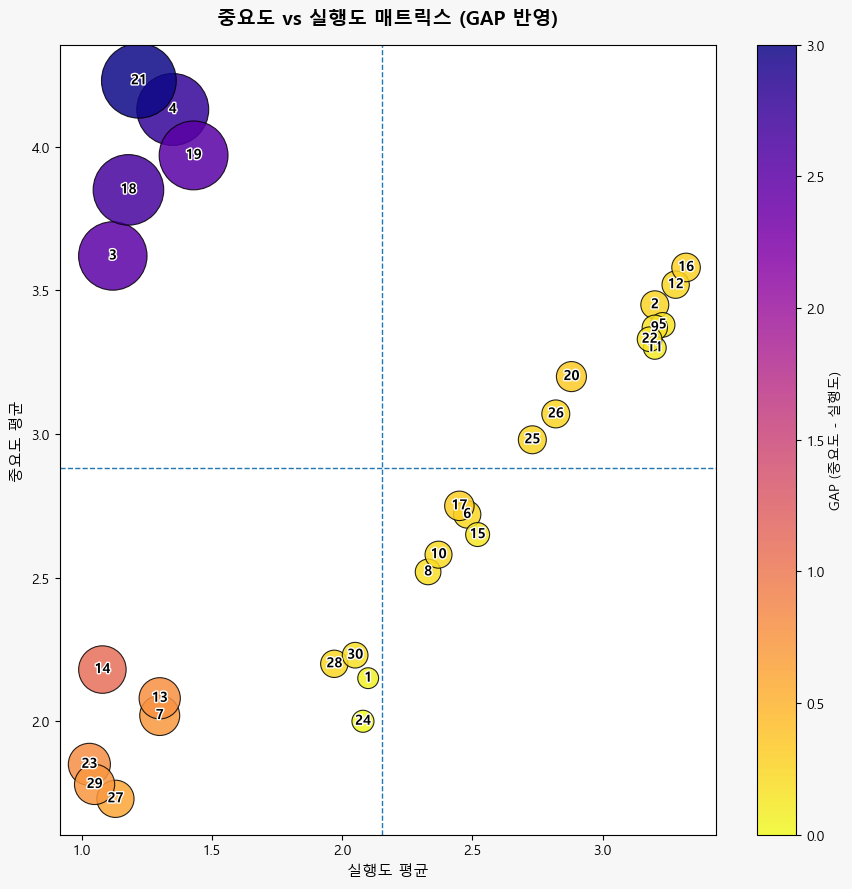

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patheffects

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plot_df = summary_df.copy().reset_index(drop=True)
plot_df["번호"] = plot_df.index + 1

x = plot_df["실행도 평균"].to_numpy()
y = plot_df["중요도 평균"].to_numpy()
gap = plot_df["GAP"].to_numpy()

sizes = (np.abs(gap) + 0.2) * 900

# GAP 기반 색상 강도 맵
norm = plt.Normalize(gap.min(), gap.max())
cmap = plt.cm.RdYlBu_r  # GAP 클수록 따뜻한 색

colors = cmap(norm(gap))

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor("#F7F7F7")
ax.set_facecolor("white")

# 기준선
x_mean = x.mean()
y_mean = y.mean()

ax.axvline(x_mean, linestyle="--", linewidth=1)
ax.axhline(y_mean, linestyle="--", linewidth=1)

# Scatter
sc = ax.scatter(
    x, y,
    s=sizes,
    c=gap,
    cmap=plt.cm.plasma_r,
    vmin=0,
    vmax=3,
    edgecolors="black",
    linewidths=0.8,
    alpha=0.85
)

# 번호 라벨
for i in range(len(plot_df)):
    ax.text(
        x[i], y[i],
        str(plot_df["번호"][i]),
        ha="center", va="center",
        fontsize=10, fontweight="bold",
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=2, foreground="white")
        ]
    )

# 축 / 제목
ax.set_xlabel("실행도 평균", fontsize=11)
ax.set_ylabel("중요도 평균", fontsize=11)

ax.set_title("중요도 vs 실행도 매트릭스 (GAP 반영)",
             fontsize=14, weight="bold", pad=15)

# 컬러바
cbar = plt.colorbar(sc)
cbar.set_label("GAP (중요도 - 실행도)", fontsize=10)

plt.tight_layout()
plt.show()

## 결과 저장

In [54]:
summary_df.to_excel("mock_analysis_result.xlsx", index=False)